<a href="https://colab.research.google.com/github/ZeyadArafat/Autonomous-Vehicle-Perception-Module/blob/main/Supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf


In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [ ]:
import numpy as np

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)
print("Number of classes:", len(np.unique(y_train)))


Training set: (50000, 32, 32, 3) (50000, 1)
Test set: (10000, 32, 32, 3) (10000, 1)
Number of classes: 10


/tmp/ipykernel_501/3274145935.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel(class_names[int(y_train[i])])


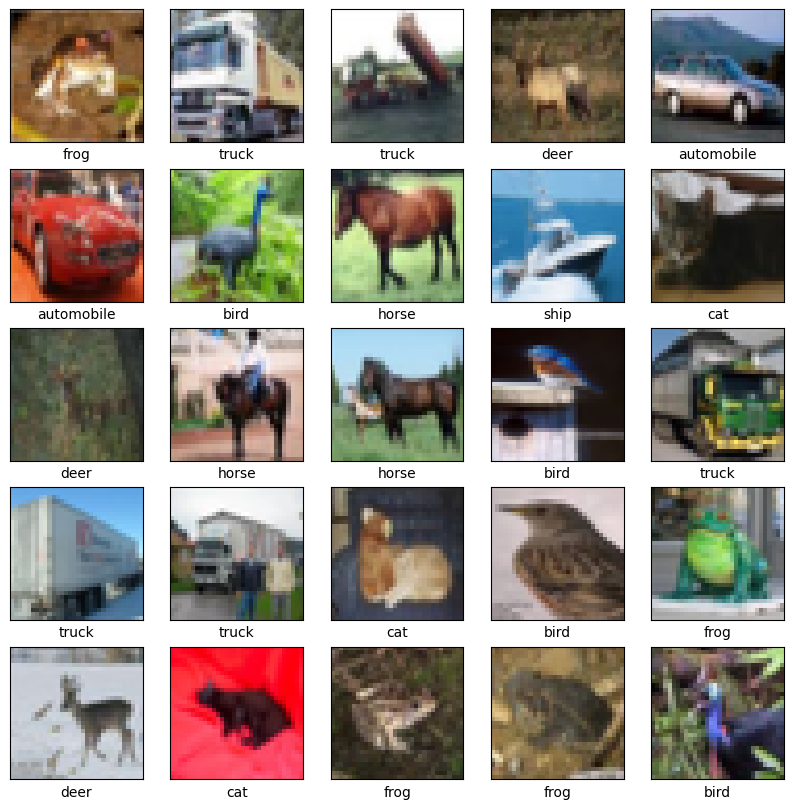

In [ ]:
import matplotlib.pyplot as plt

# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[int(y_train[i])])
plt.show()


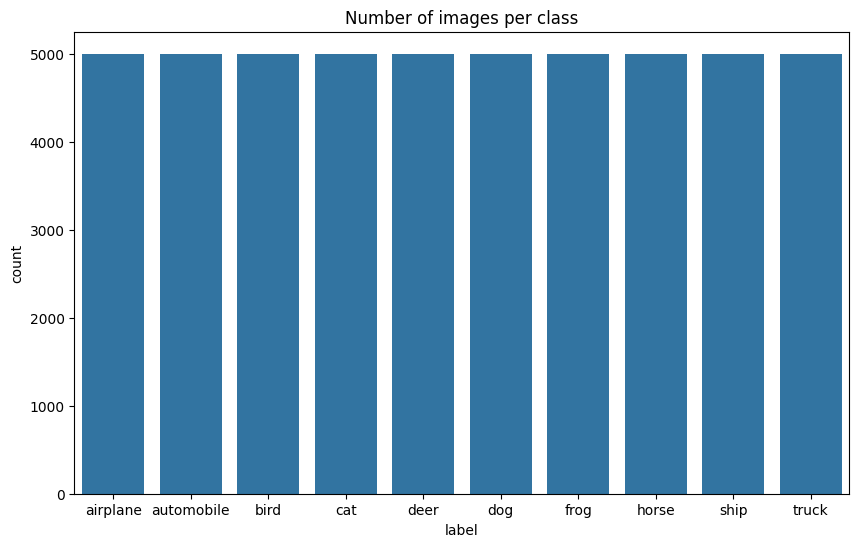

In [ ]:
import seaborn as sns
import pandas as pd

y_train_flat = y_train.flatten()
df = pd.DataFrame({'label': y_train_flat})
plt.figure(figsize=(10,6))
sns.countplot(x='label', data=df)
plt.xticks(ticks=range(10), labels=class_names)
plt.title('Number of images per class')
plt.show()


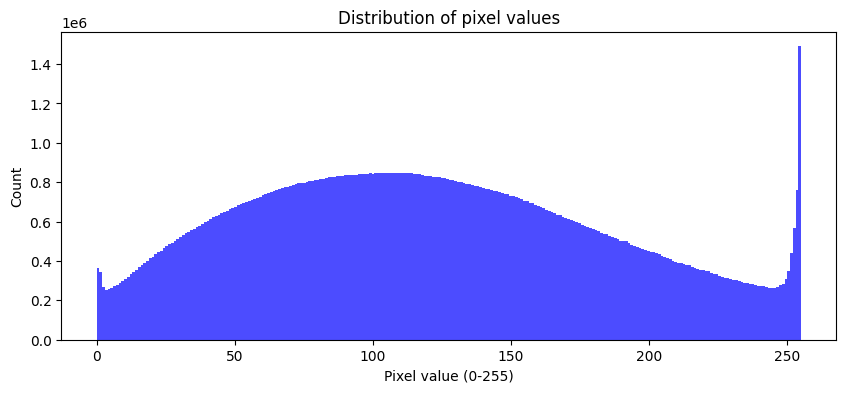

In [ ]:
plt.figure(figsize=(10,4))
plt.hist(X_train.ravel(), bins=256, color='blue', alpha=0.7)
plt.title("Distribution of pixel values")
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Count")
plt.show()


In [ ]:
means = X_train.mean(axis=(0,1,2))
stds = X_train.std(axis=(0,1,2))
print("Channel means:", means)
print("Channel stds:", stds)


Channel means: [125.30691805 122.95039414 113.86538318]
Channel stds: [62.99321928 62.08870764 66.70489964]


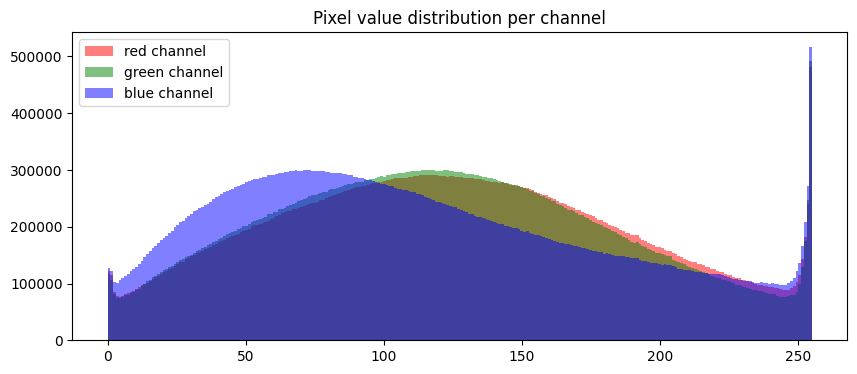

In [ ]:
colors = ['red', 'green', 'blue']
plt.figure(figsize=(10,4))
for i, color in enumerate(colors):
    plt.hist(X_train[:,:,:,i].ravel(), bins=256, color=color, alpha=0.5, label=f'{color} channel')
plt.title("Pixel value distribution per channel")
plt.legend()
plt.show()


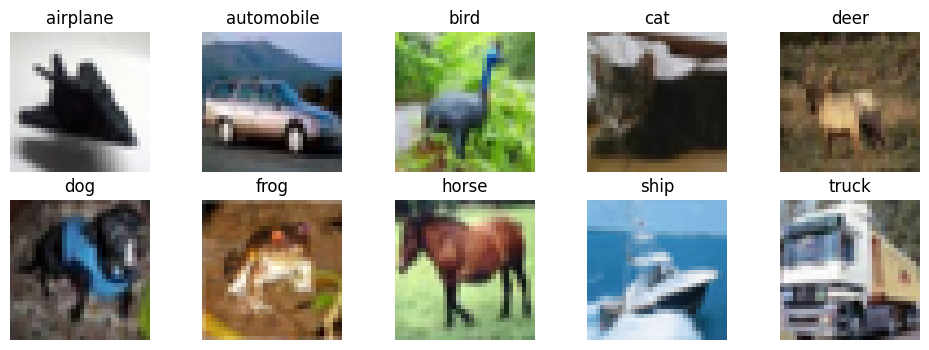

In [ ]:
plt.figure(figsize=(12,4))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[idx])
    plt.title(class_names[i])
    plt.axis('off')
plt.show()


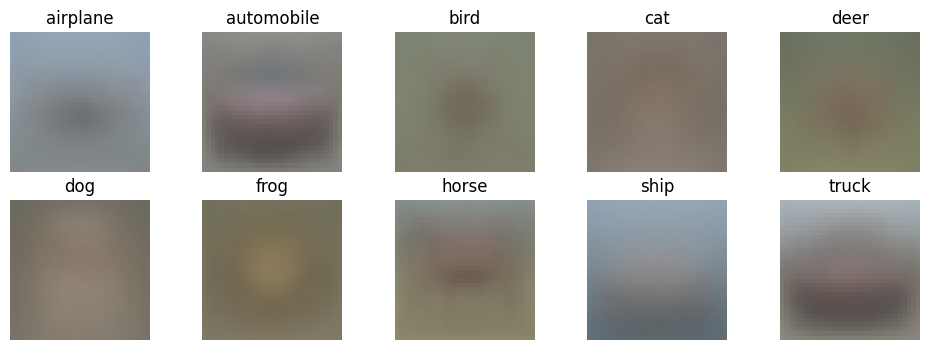

In [ ]:
plt.figure(figsize=(12,4))
for i in range(10):
    idx = np.where(y_train == i)[0]
    mean_img = X_train[idx].mean(axis=0).astype(np.uint8)
    plt.subplot(2,5,i+1)
    plt.imshow(mean_img)
    plt.title(class_names[i])
    plt.axis('off')
plt.show()
